В блокноте обучается модель для предсказания ключевых точек. Архив датасета был заранее скопирован на гугл диск и картинки берутся оттуда.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [2]:
root_dir = '/content/gdrive/MyDrive/Colab Notebooks/fr/'
checkpoint_dir = root_dir + 'checkpoints/'
data_dir = 'cropped/'

In [3]:
import os
os.makedirs(checkpoint_dir, exist_ok=True)

In [4]:
!unzip -q '/content/gdrive/MyDrive/Colab Notebooks/fr/cropped.zip'

In [5]:
!pip install albumentationsx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.4/551.4 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 38.4 MB/s eta 0:00:00
  Attempting uninstall: albucore
    Found existing installation: albucore 0.0.24
    Uninstalling albucore-0.0.24:
      Successfully uninstalled albucore-0.0.24
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 2.0.8 requires albucore==0.0.24, but you have albucore 0.1.6 which is incompatible.


In [6]:
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

from tqdm.notebook import tqdm


Модель (на основе оригинального репозитория статьи https://github.com/princeton-vl/pytorch_stacked_hourglass).

In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)


class HourglassBlock(nn.Module):
    def __init__(self, n, f):
        """
        Recursive Hourglass module.

        :param n: Number of downsampling levels (depth of the hourglass).
        :param f: Number of feature channels.
        """
        super().__init__()
        self.up1 = ResidualBlock(f, f)
        # Lower branch
        self.pool1 = nn.MaxPool2d(2, 2)
        self.low1 = ResidualBlock(f, f)
        self.n = n
        # Recursive hourglass
        if self.n > 1:
            self.low2 = HourglassBlock(n-1, f)
        else:
            self.low2 = ResidualBlock(f, f)
        self.low3 = ResidualBlock(f, f)
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        up1  = self.up1(x)
        pool1 = self.pool1(x)
        low1 = self.low1(pool1)
        low2 = self.low2(low1)
        low3 = self.low3(low2)
        up2  = self.up2(low3)
        return up1 + up2


class HourglassNet(nn.Module):
    def __init__(self, nstack, depth, inp_dim, oup_dim, bn=False):
        super().__init__()
        self.nstack = nstack

        self.pre = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResidualBlock(64, 128),
            nn.MaxPool2d(2, 2),
            ResidualBlock(128, 128),
            ResidualBlock(128, inp_dim),
        )

        self.hgs = nn.ModuleList([
            HourglassBlock(depth, inp_dim) for _ in range(nstack)
        ])

        self.features = nn.ModuleList([
            ResidualBlock(inp_dim, inp_dim) for _ in range(nstack)
        ])

        self.outs = nn.ModuleList([
            nn.Conv2d(inp_dim, oup_dim, 1) for _ in range(nstack)
        ])

        self.merge_features = nn.ModuleList([
            nn.Conv2d(inp_dim, inp_dim, 1) for _ in range(nstack-1)
        ])

        self.merge_preds = nn.ModuleList([
            nn.Conv2d(oup_dim, inp_dim, 1) for _ in range(nstack-1)
        ])

    def forward(self, x):
        x = self.pre(x)
        combined_hm_preds = []
        for i in range(self.nstack):
            hg = self.hgs[i](x)
            feature = self.features[i](hg)
            preds = self.outs[i](feature)
            combined_hm_preds.append(preds)
            if i < self.nstack - 1:
                x = x + self.merge_preds[i](preds) + self.merge_features[i](feature)
        return combined_hm_preds


Функции для создания хитмапов и обратного получения точек по хитмапам.

In [8]:
def create_heatmap(size, landmark, sigma=2):
    """
    Создаёт один heatmap с гауссовым ядром вокруг точки.

    :param size: (height, width) — размер heatmap'а
    :param landmark:(x, y) — координаты точки
    :param sigma
    :return: heatmap массив
    """
    x, y = landmark
    h, w = size

    # Обрезаем координаты, чтобы не выйти за пределы изображения
    x = min(max(0, int(x)), w - 1)
    y = min(max(0, int(y)), h - 1)

    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    heatmap = np.exp(-((yy - y)**2 + (xx - x)**2) / (2 * sigma**2))
    return heatmap


def landmarks_to_heatmaps(image_shape, landmarks, sigma=2):
    """
    Преобразует список из N точек в набор из N heatmap'ов.

    :param image_shape: исходный размер изображения (H, W)
    :param landmarks: список из N пар координат [(x1, y1), (x2, y2), ..., (xN, yN),]
    :param sigma:
    :return: массив heatmap'ов вида [N, H, W]
    """
    heatmaps = []

    for (x, y) in landmarks:
        hm = create_heatmap(image_shape, (x, y), sigma=sigma)
        heatmaps.append(hm)

    return np.array(heatmaps)


def heatmaps_to_points(heatmaps):
    heatmaps = F.interpolate(heatmaps, scale_factor=4.0, mode='bilinear', align_corners=False)
    n, c, h, w = heatmaps.shape
    index = heatmaps.view(n, c, 1, -1).argmax(dim=-1)
    points = torch.cat([index % w, index // w], dim=2)
    return points


Создание классов для датасетов.

In [9]:
class FaceDataset(Dataset):
    def __init__(self, path, dataframe, transform):
        self.path = path
        self.data = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, item):
        img_name = self.data.index[item]
        img_path = f'{self.path}{img_name}'

        img = Image.open(img_path)
        img = np.asarray(img)

        landmarks = self.data.iloc[item]
        landmarks = np.asarray(landmarks, dtype=float).reshape(-1, 2)

        transformed = self.transform(image=img, keypoints=landmarks, keypoint_labels=landmark_labels)
        image, keypoints = transformed["image"], transformed["keypoints"]

        target = torch.tensor(landmarks_to_heatmaps((64, 64), keypoints / 4.0), dtype=torch.float32)

        return image, target


In [21]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

landmark_labels = ['lefteye', 'righteye', 'nose', 'leftmouth', 'rightmouth']
landmark_flip_mapping = {
    'lefteye': 'righteye',
    'righteye': 'lefteye',
    'leftmouth': 'rightmouth',
    'rightmouth': 'leftmouth',
}

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ToGray(p=0.1),
    A.Affine(
        scale=(0.75, 1.25),
        rotate=(-30, 30),
        balanced_scale=True, p=0.5),
    A.OneOf([
        A.RandomBrightnessContrast(p=1.0),
        A.RandomGamma(p=1.0),
    ], p=0.2),
    A.OneOf([
        A.MotionBlur(p=1.0),
        A.GaussNoise(p=1.0),
    ], p=0.1),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
], keypoint_params=A.KeypointParams(
    coord_format="xy",
    label_fields=['keypoint_labels'],
    label_mapping={'HorizontalFlip': {'keypoint_labels': landmark_flip_mapping}},
    remove_invisible=False)
)

test_transform = A.Compose([
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])


# Создаем обратную аугментацию к A.Normalize

inv_mean = [-m / s for m, s in zip(mean, std)]
inv_std = [1.0 / s for s in std]

unnormalize_transform = A.Normalize(
    mean=inv_mean,
    std=inv_std,
    max_pixel_value=1.0  # Важно: 1.0, так как на вход идет уже float-картинка
)


In [26]:
BATCH_SIZE = 32

train_df = pd.read_csv(f'{data_dir}train_landmarks.csv', index_col=0)
val_df = pd.read_csv(f'{data_dir}val_landmarks.csv', index_col=0)
test_df = pd.read_csv(f'{data_dir}test_landmarks.csv', index_col=0)

train_dataset = FaceDataset(f'{data_dir}train/', train_df, train_transform)
val_dataset = FaceDataset(f'{data_dir}val/', val_df, test_transform)
test_dataset = FaceDataset(f'{data_dir}test/', test_df, test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Обучение модели.

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [27]:
model = HourglassNet(nstack=2, depth=4, inp_dim=256, oup_dim=5)
model = model.to(device)

In [14]:
sum([len(p.ravel()) for p in model.parameters()])

6414282

In [28]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5, min_lr=1e-6)
criterion = nn.MSELoss()

In [29]:
train_loss_list = []
val_loss_list = []
lr_list = []

In [17]:
def fit_one_epoch(model, loader, criterion, optimizer, prefix=''):
    loss_list = []

    model.train()
    batch_tqdm = tqdm(loader, leave=True)
    for batch_x, batch_y in batch_tqdm:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)
        loss = sum(criterion(output, batch_y) for output in outputs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_list.append(loss.item())
        batch_tqdm.set_description(f"{prefix}train_loss={loss.item():.4f}")

    mean_loss = np.mean(loss_list)
    batch_tqdm.set_description(f"{prefix}train_loss={mean_loss:.4f}")

    return mean_loss


def eval_one_epoch(model, loader, criterion, prefix=''):
    loss_list = []

    model.eval()
    with torch.no_grad():
        batch_tqdm = tqdm(loader, leave=True)
        for batch_x, batch_y in batch_tqdm:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)
            loss = sum(criterion(output, batch_y) for output in outputs)

            loss_list.append(loss.item())
            batch_tqdm.set_description(f"{prefix}val_loss={loss.item():.4f}")

    mean_loss = np.mean(loss_list)
    batch_tqdm.set_description(f"{prefix}val_loss={mean_loss:.4f}")

    return mean_loss


def train(start=0):
    best_val_loss = min(val_loss_list, default=float('inf'))

    epoch_tqdm = tqdm(range(start, start + epochs), leave=True)
    for epoch in epoch_tqdm:
        train_loss = fit_one_epoch(model, train_loader, criterion, optimizer, prefix=f'Epoch [{epoch + 1}/{start + epochs}] ')
        train_loss_list.append(train_loss)

        val_loss = eval_one_epoch(model, val_loader, criterion, prefix=f'Epoch [{epoch + 1}/{start + epochs}] ')
        val_loss_list.append(val_loss)

        scheduler.step(val_loss)
        lr = scheduler.get_last_lr()
        lr_list.append(lr)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'{checkpoint_dir}epoch_{epoch + 1}_best_val_loss.pth')

        if (epoch + 1) % 5 == 0:
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss_list': train_loss_list,
                'val_loss_list': val_loss_list,
                'lr_list': lr_list,
            }, f'{checkpoint_dir}epoch_{epoch + 1}.pth')

        epoch_tqdm.set_description(f"Epoch [{epoch + 1}/{start + epochs}], train_loss_mean={train_loss_list[-1]:.4f}, val_loss_mean={val_loss_list[-1]:.4f}, lr={lr}")


In [18]:
def plot_samples(loader, n=5):
    images, outputs = next(iter(loader))
    images = images[:n].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(images)

    images = unnormalize_transform(image=images.cpu().permute(0, 2, 3, 1).numpy())['image']
    points = heatmaps_to_points(outputs[-1].cpu())

    plt.figure(figsize=(10, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i])
        plt.scatter(points[i, :, 0], points[i, :, 1], s=20, marker='x', c='b')
        plt.axis("off")
    plt.show()


Обучение на 20 эпох.

In [19]:
epochs = 20

In [30]:
train()

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

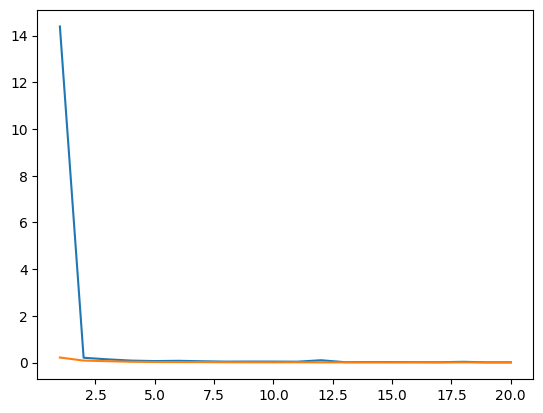

In [31]:
plt.plot(range(1, len(train_loss_list) + 1), train_loss_list)
plt.plot(range(1, len(val_loss_list) + 1), val_loss_list)


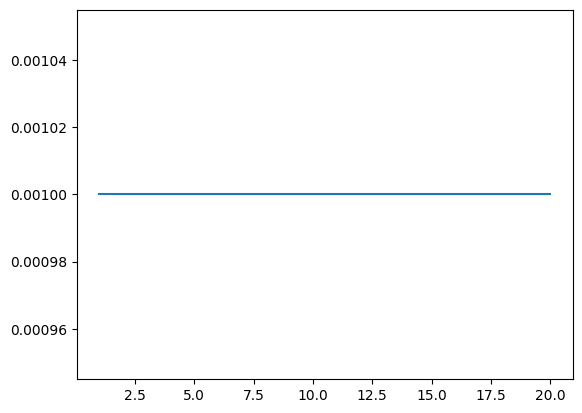

In [32]:
plt.plot(range(1, len(lr_list) + 1), lr_list)

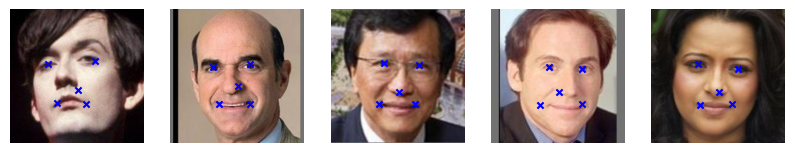

In [33]:
plot_samples(val_loader)

И еще 20 эпох.

In [34]:
train(start=20)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

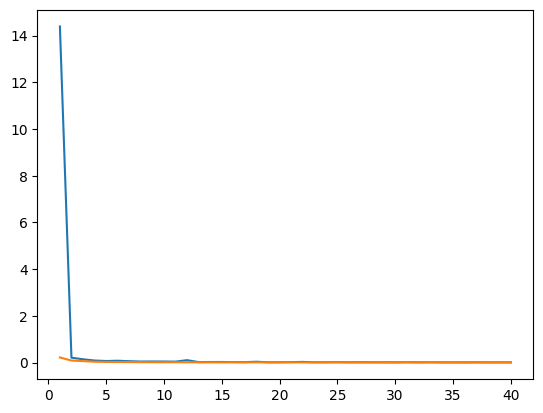

In [35]:
plt.plot(range(1, len(train_loss_list) + 1), train_loss_list)
plt.plot(range(1, len(val_loss_list) + 1), val_loss_list)

Лосс в другом масштабе (с 5 эпохи).

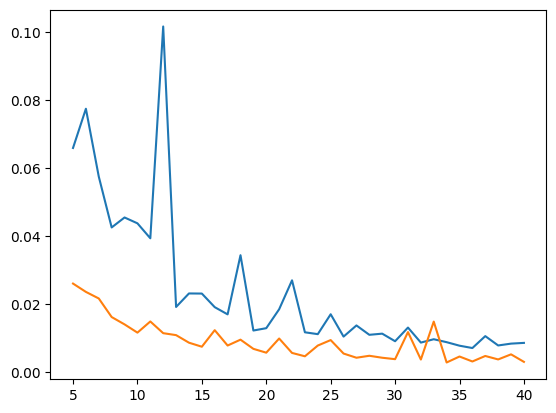

In [41]:
plt.plot(range(5, len(train_loss_list) + 1), train_loss_list[4:])
plt.plot(range(5, len(val_loss_list) + 1), val_loss_list[4:])

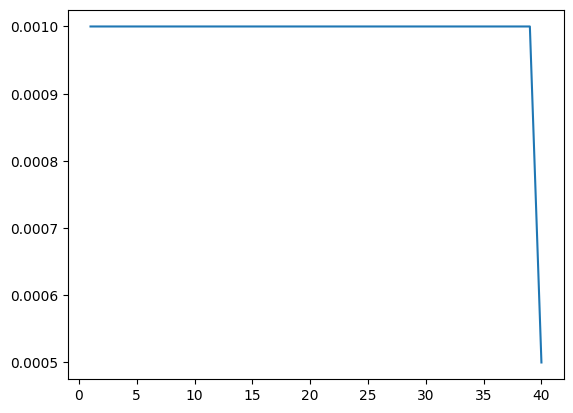

In [36]:
plt.plot(range(1, len(lr_list) + 1), lr_list)

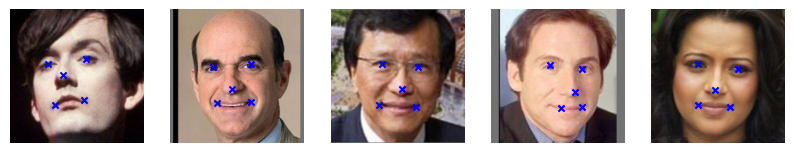

In [37]:
plot_samples(val_loader)

Еще 20 эпох.

In [42]:
train(start=40)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

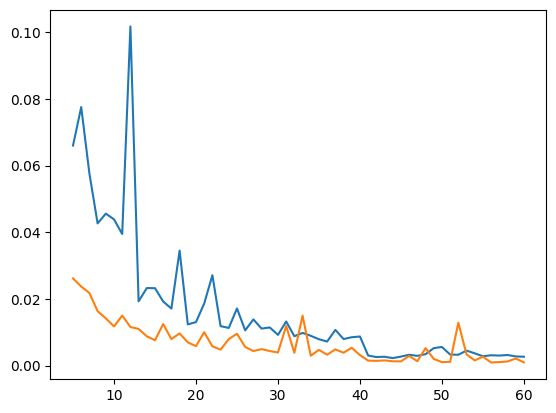

In [43]:
plt.plot(range(5, len(train_loss_list) + 1), train_loss_list[4:])
plt.plot(range(5, len(val_loss_list) + 1), val_loss_list[4:])

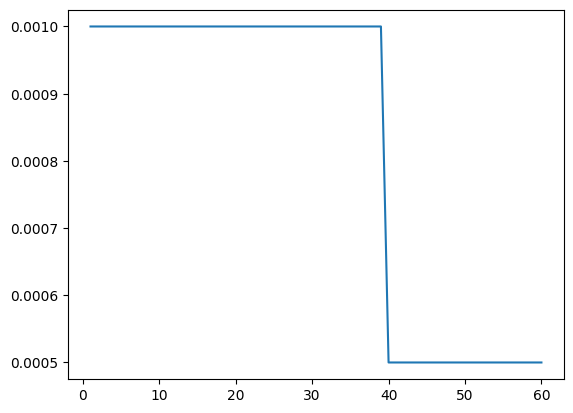

In [44]:
plt.plot(range(1, len(lr_list) + 1), lr_list)

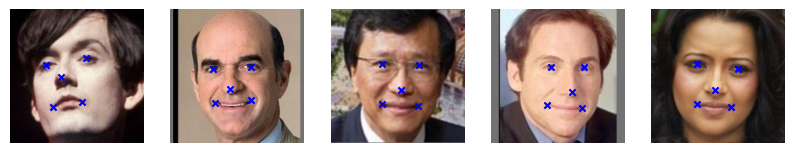

In [45]:
plot_samples(val_loader)

Смотрим лосс на тесте.

In [46]:
test_loss = eval_one_epoch(model, test_loader, criterion)

  0%|          | 0/32 [00:00<?, ?it/s]

Смотрим хитмапы на тесте.

In [47]:
def plot_heatmaps(loader, n=5):
    images, _ = next(iter(loader))
    images = images[:n].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(images)

    images = unnormalize_transform(image=images.cpu().permute(0, 2, 3, 1).numpy())['image']
    outputs = [output.cpu() for output in outputs]
    points = heatmaps_to_points(outputs[-1])

    plt.figure(figsize=(10, 30))
    for i in range(n):
        plt.subplot(3 * n, 5, i * 15 + 1)
        plt.imshow(images[i])
        plt.scatter(points[i, :, 0], points[i, :, 1], s=20, marker='x', c='b')
        plt.axis("off")

        for j in range(2):
            for k in range(5):
                plt.subplot(3 * n, 5, i * 15 + 5 + j * 5 + k + 1)
                plt.imshow(outputs[j][i, k])
                plt.axis("off")

    plt.show()


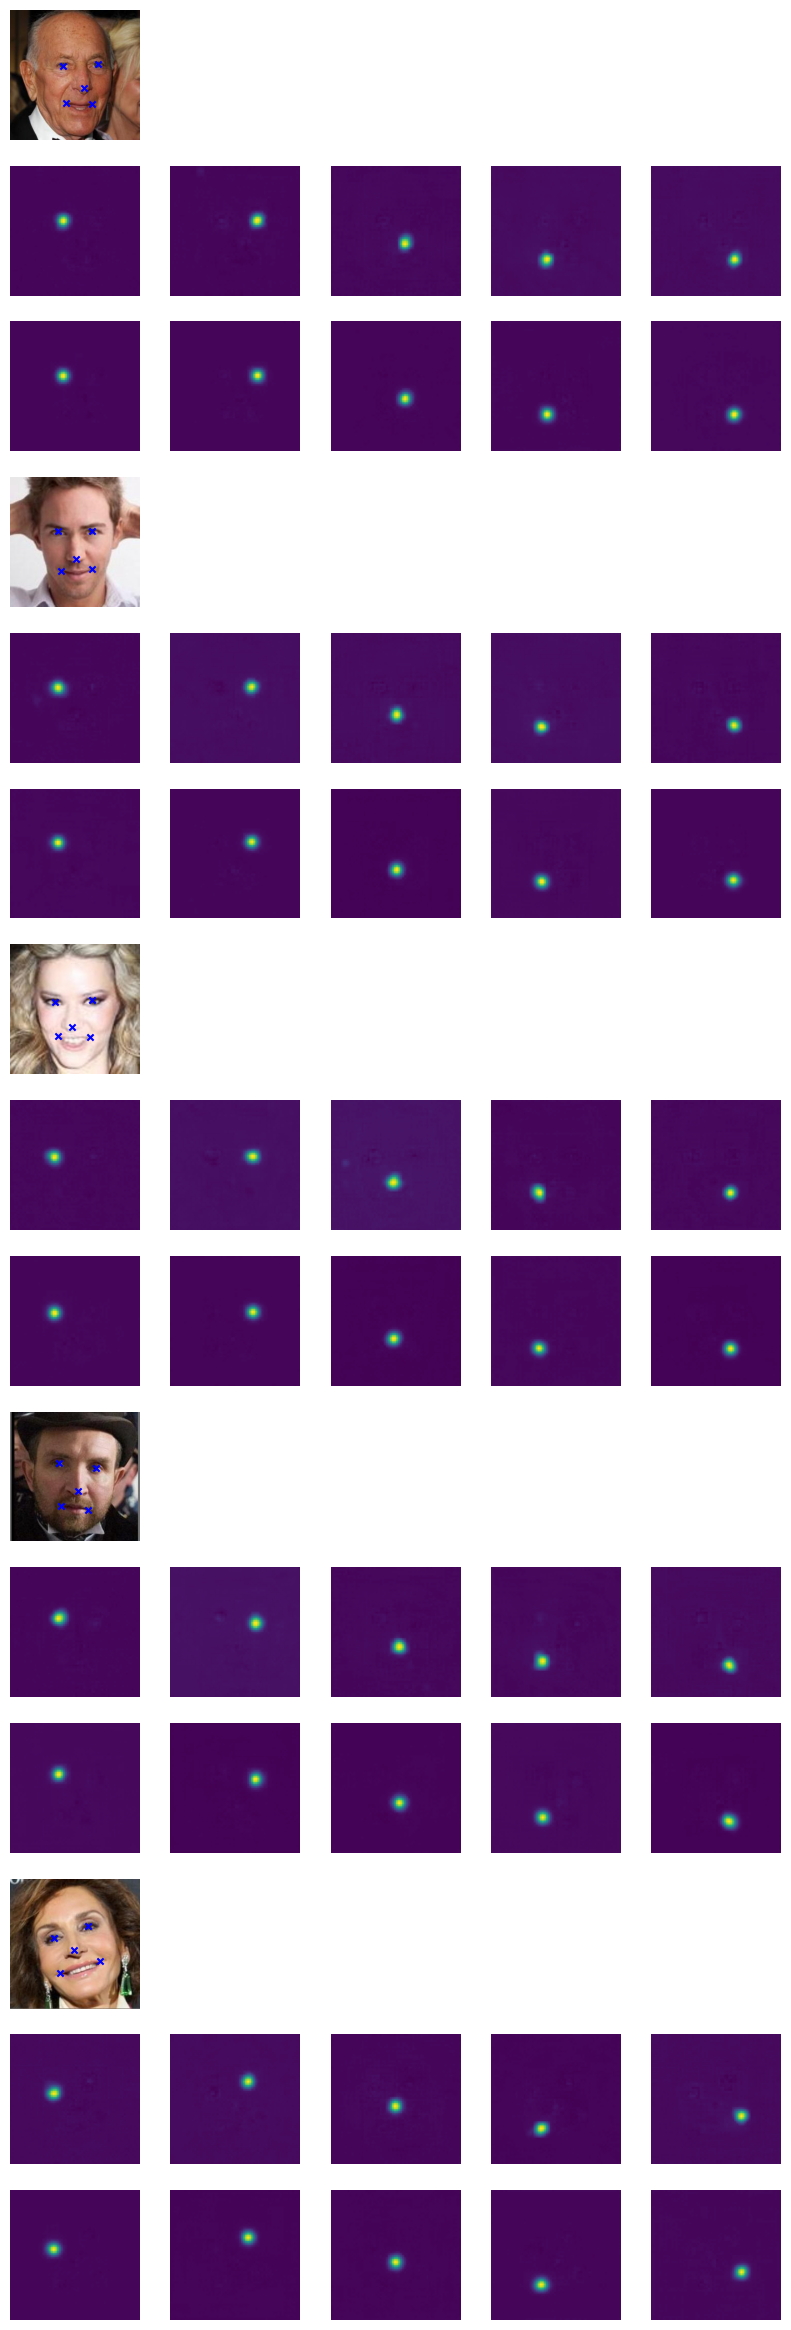

In [48]:
plot_heatmaps(test_loader)